# Tarefa: Clustering — K-Means, Agglomerative Clustering (Hierárquico) e DBSCAN

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados

## Dataset Iris — Comparação de Algoritmos de Agrupamento

**Objetivo:** Aplicar os algoritmos K-Means, Agglomerative Clustering (Hierárquico) e DBSCAN sobre o mesmo conjunto de dados (Iris) e avaliar qual modelo entrega a melhor estrutura de agrupamento, utilizando o Índice de Silhueta (Silhouette Score) e o Índice Davies-Bouldin (DBI) como métricas de avaliação.

- **Silhouette Score:** varia de -1 a 1. Quanto mais próximo de 1, mais compactos e mais separados estão os grupos (Ideal: **maior** valor).
- **Davies-Bouldin Index (DBI):** mede a similaridade entre clusters. Quanto mais separados e compactos, menor o índice (Ideal: **menor** valor).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento dos Dados

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['Especie'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]-2} atributos')
print(f'Classes   : {list(iris.target_names)}')
print(df['Especie'].value_counts())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Especie
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa



Dimensoes: 150 amostras x 4 atributos
Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Especie
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### 2. Análise Exploratória dos Dados

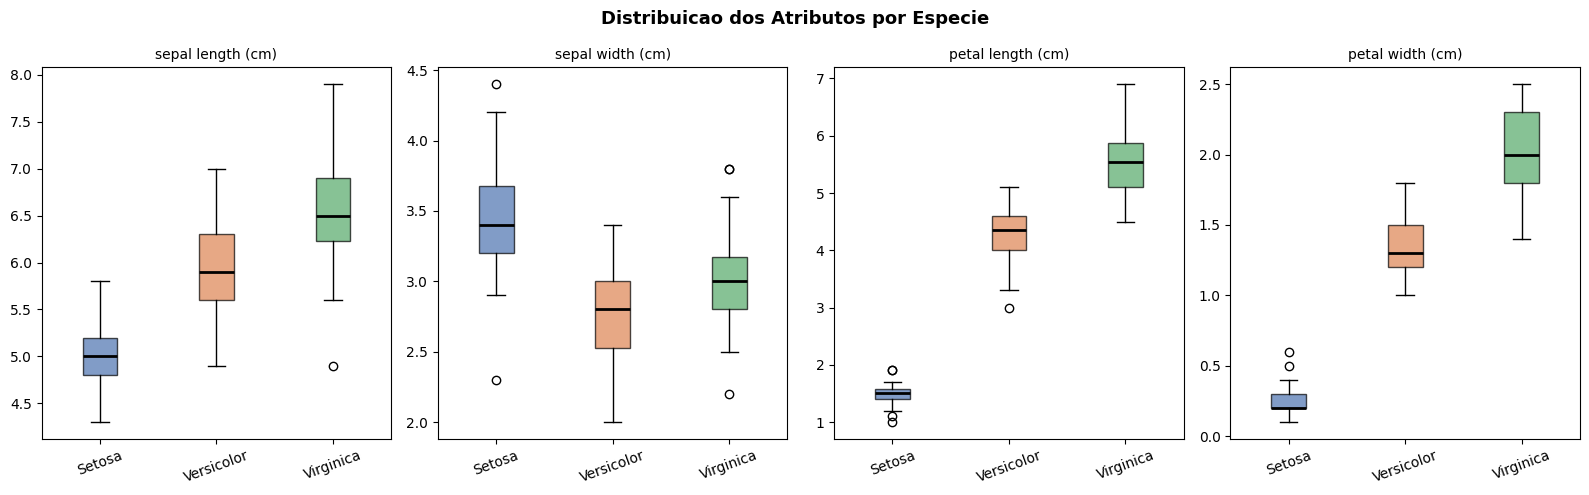

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

cores = {'Setosa': '#4C72B0', 'Versicolor': '#DD8452', 'Virginica': '#55A868'}

for ax, feature in zip(axes, iris.feature_names):
    grupos = [df[df['Especie'] == esp][feature].values for esp in cores]
    bp = ax.boxplot(grupos, patch_artist=True, tick_labels=list(cores.keys()))
    for patch, cor in zip(bp['boxes'], cores.values()):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(feature, fontsize=10)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribuicao dos Atributos por Especie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

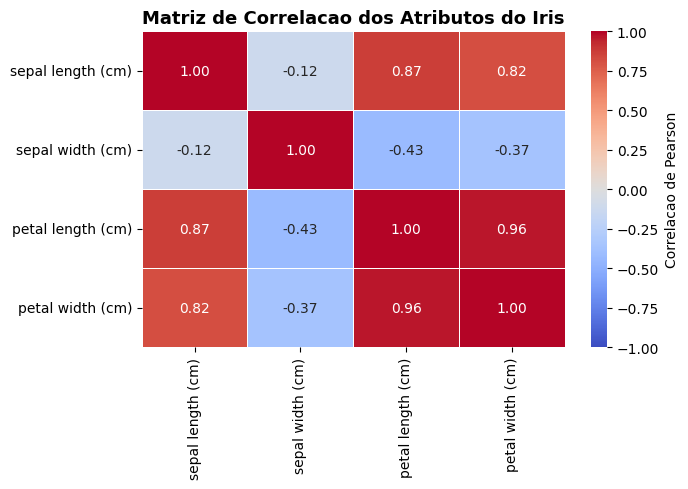

In [4]:
corr_matrix = df[iris.feature_names].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlacao de Pearson'}
)
plt.title('Matriz de Correlacao dos Atributos do Iris', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Pré-processamento — Padronização dos Dados\n\nOs algoritmos de clustering baseados em distância (K-Means, Hierárquico e DBSCAN) sao sensiveis a escala dos atributos. Por isso, os dados sao padronizados (media 0, desvio padrao 1) antes de qualquer agrupamento.

In [5]:
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Media pos-escala (deve ser ~0):', X_scaled.mean(axis=0).round(6))
print('Desvio pos-escala (deve ser ~1):', X_scaled.std(axis=0).round(6))

Media pos-escala (deve ser ~0): [-0. -0. -0. -0.]
Desvio pos-escala (deve ser ~1): [1. 1. 1. 1.]


### 4. Aplicação dos Algoritmos de Clustering\n\nOs tres algoritmos sao aplicados sobre os dados padronizados, buscando **k=3** grupos (K-Means e Hierarquico recebem k=3 explicitamente; o DBSCAN descobre o numero de grupos sozinho a partir da densidade, com os parametros padrao `eps=0.5` e `min_samples=5`).

In [6]:
resultados = []

# K-Means 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
dbi_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
resultados.append(['K-Means', 3, sil_kmeans, dbi_kmeans])

# Agglomerative Clustering (Hierarquico)
agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_scaled)
sil_agglo = silhouette_score(X_scaled, labels_agglo)
dbi_agglo = davies_bouldin_score(X_scaled, labels_agglo)
resultados.append(['Agglomerative (Hierarquico)', 3, sil_agglo, dbi_agglo])

# DBSCAN (parametros padrao)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = list(labels_dbscan).count(-1)

if n_clusters_dbscan >= 2:
    mask = labels_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    dbi_dbscan = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
else:
    sil_dbscan, dbi_dbscan = np.nan, np.nan

resultados.append(['DBSCAN (eps=0.5)', n_clusters_dbscan, sil_dbscan, dbi_dbscan])

df_resultados = pd.DataFrame(resultados, columns=['Algoritmo', 'N Clusters', 'Silhouette Score', 'DBI'])
print(f'DBSCAN (eps=0.5) encontrou {n_clusters_dbscan} cluster(s) e classificou {n_noise_dbscan} pontos como ruido (label -1)')
print()
display(df_resultados.round(4))

DBSCAN (eps=0.5) encontrou 2 cluster(s) e classificou 34 pontos como ruido (label -1)



,Algoritmo,N Clusters,Silhouette Score,DBI
0,K-Means,3,0.4599,0.8336
1,Agglomerative (Hierarquico),3,0.4467,0.8035
2,DBSCAN (eps=0.5),2,0.6559,0.4942


### 5. Visualização dos Agrupamentos (Projeção PCA 2D)\n\nPara visualizar os resultados em 2D, os dados padronizados sao projetados nos dois primeiros componentes principais (PCA). Essa projecao e usada apenas para visualizacao — o agrupamento em si foi feito no espaco original de 4 dimensoes.

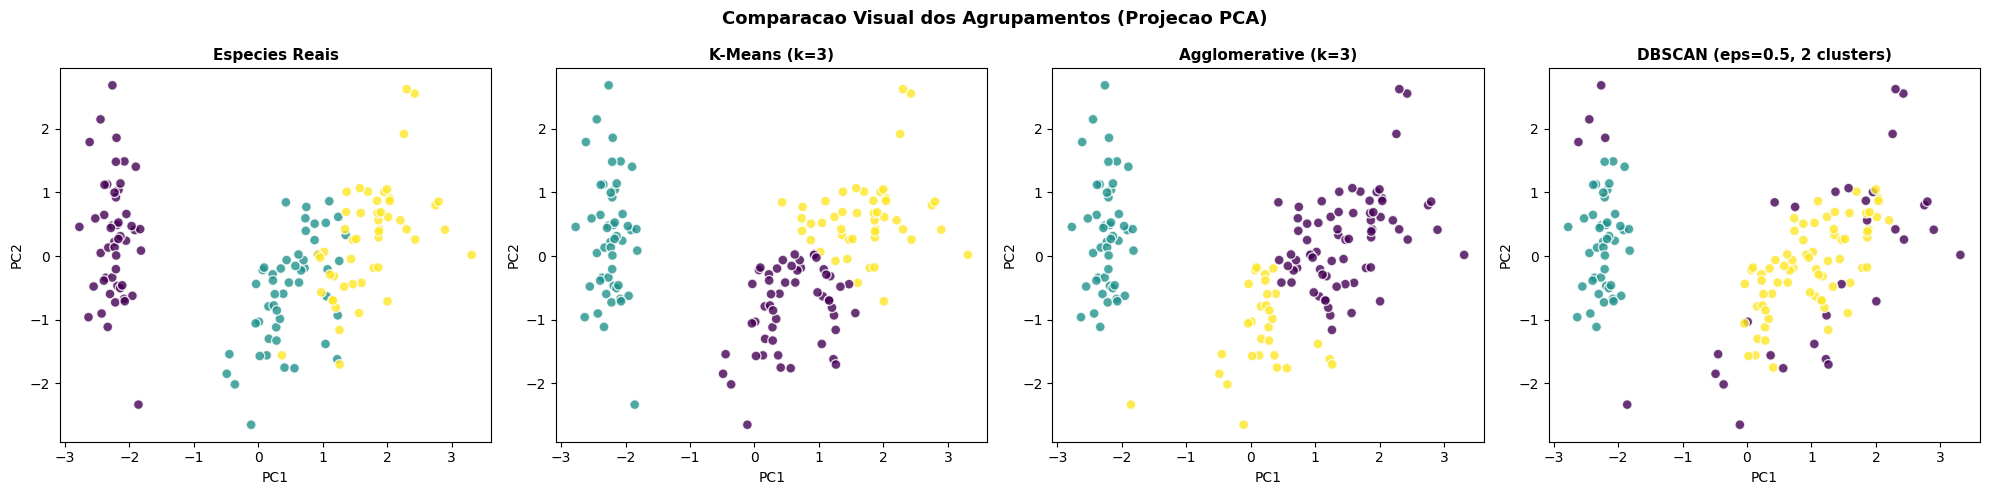

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

paineis = [
    ('Especies Reais', y, iris.target_names),
    ('K-Means (k=3)', labels_kmeans, None),
    ('Agglomerative (k=3)', labels_agglo, None),
    (f'DBSCAN (eps=0.5, {n_clusters_dbscan} clusters)', labels_dbscan, None),
]

for ax, (titulo, labels, _) in zip(axes, paineis):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8, edgecolors='white')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Comparacao Visual dos Agrupamentos (Projecao PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Comparação das Métricas de Avaliação

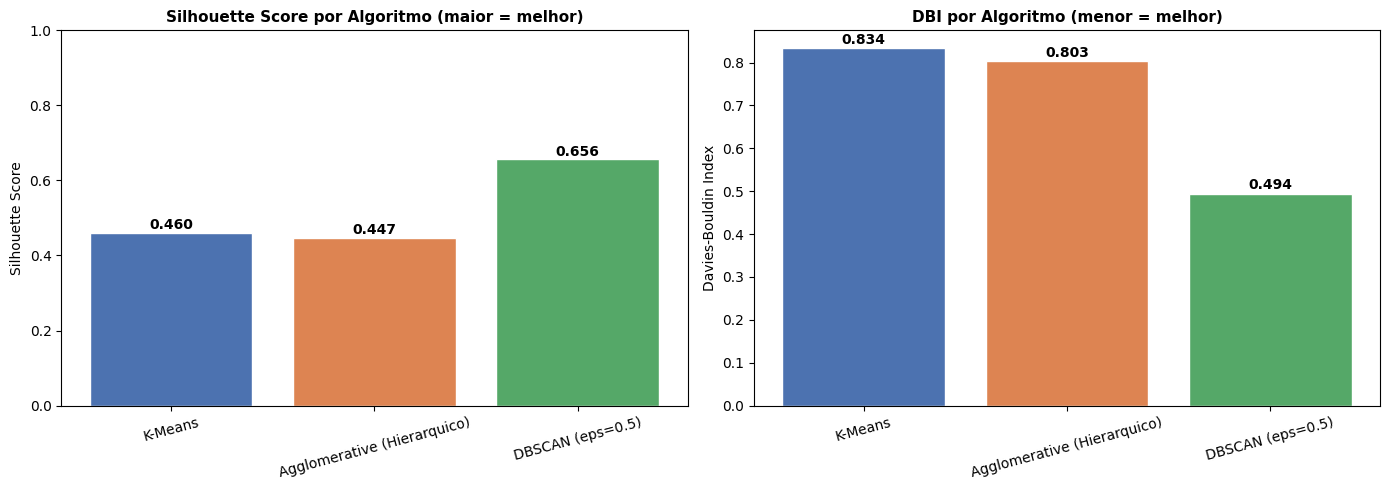

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_bar = ['#4C72B0', '#DD8452', '#55A868']

ax = axes[0]
bars = ax.bar(df_resultados['Algoritmo'], df_resultados['Silhouette Score'], color=cores_bar, edgecolor='white')
for bar, val in zip(bars, df_resultados['Silhouette Score']):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por Algoritmo (maior = melhor)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0, 1)

ax = axes[1]
bars = ax.bar(df_resultados['Algoritmo'], df_resultados['DBI'], color=cores_bar, edgecolor='white')
for bar, val in zip(bars, df_resultados['DBI']):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('DBI por Algoritmo (menor = melhor)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 7. Ajuste do DBSCAN (eps=0.8)\n\nComo o DBSCAN com os parametros padrao (`eps=0.5`, `min_samples=5`) nao encontrou os 3 grupos originais, o `eps` e aumentado para `0.8` (raio de vizinhanca maior = pontos mais distantes ainda sao considerados vizinhos), e o algoritmo e executado novamente.

In [9]:
dbscan_v2 = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan_v2 = dbscan_v2.fit_predict(X_scaled)
n_clusters_v2 = len(set(labels_dbscan_v2)) - (1 if -1 in labels_dbscan_v2 else 0)
n_noise_v2 = list(labels_dbscan_v2).count(-1)

if n_clusters_v2 >= 2:
    mask_v2 = labels_dbscan_v2 != -1
    sil_v2 = silhouette_score(X_scaled[mask_v2], labels_dbscan_v2[mask_v2])
    dbi_v2 = davies_bouldin_score(X_scaled[mask_v2], labels_dbscan_v2[mask_v2])
else:
    sil_v2, dbi_v2 = np.nan, np.nan

print(f'DBSCAN (eps=0.8) encontrou {n_clusters_v2} cluster(s) e classificou {n_noise_v2} pontos como ruido (label -1)')
print(f'Silhouette Score: {sil_v2:.4f}')
print(f'DBI             : {dbi_v2:.4f}')
print()

df_dbscan_comp = pd.DataFrame([
    ['DBSCAN (eps=0.5)', n_clusters_dbscan, n_noise_dbscan, sil_dbscan, dbi_dbscan],
    ['DBSCAN (eps=0.8)', n_clusters_v2, n_noise_v2, sil_v2, dbi_v2],
], columns=['Configuracao', 'N Clusters', 'N Ruido', 'Silhouette Score', 'DBI'])
display(df_dbscan_comp.round(4))

DBSCAN (eps=0.8) encontrou 2 cluster(s) e classificou 4 pontos como ruido (label -1)
Silhouette Score: 0.5979
DBI             : 0.5688



,Configuracao,N Clusters,N Ruido,Silhouette Score,DBI
0,DBSCAN (eps=0.5),2,34,0.6559,0.4942
1,DBSCAN (eps=0.8),2,4,0.5979,0.5688


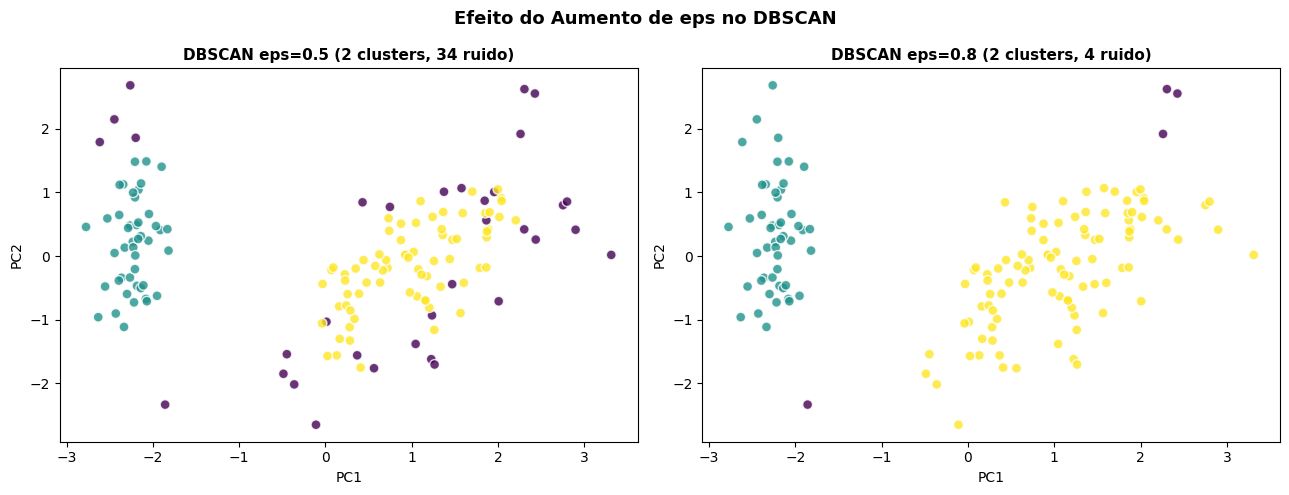

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis', s=50, alpha=0.8, edgecolors='white')
axes[0].set_title(f'DBSCAN eps=0.5 ({n_clusters_dbscan} clusters, {n_noise_dbscan} ruido)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan_v2, cmap='viridis', s=50, alpha=0.8, edgecolors='white')
axes[1].set_title(f'DBSCAN eps=0.8 ({n_clusters_v2} clusters, {n_noise_v2} ruido)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('Efeito do Aumento de eps no DBSCAN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Respostas às Questões

#### Questão 1 — Interpretando o Placar

Olhando a tabela de resultados da Seção 4 (K-Means, Hierárquico e DBSCAN todos com k=3, ou tentativa de k=3 no caso do DBSCAN):

- O **maior Silhouette Score** entre K-Means e Agglomerative foi do **K-Means** (≈0,460 contra ≈0,447 do Hierárquico) — uma diferença pequena, mas o K-Means levou vantagem.
- O **menor DBI** entre os dois também foi do **K-Means** (≈0,834 contra ≈0,803 do Hierárquico) — aqui **quem venceu foi o Agglomerative**, não o K-Means.

Ou seja, **os dois índices não concordam** sobre qual dos dois algoritmos de k=3 é o melhor: o Silhouette Score aponta o K-Means como levemente superior, enquanto o DBI aponta o Agglomerative como levemente superior. Isso acontece porque as duas métricas penalizam aspectos ligeiramente diferentes da geometria dos clusters (o Silhouette pondera separação e coesão por amostra; o DBI compara a dispersão interna de cada cluster com a distância entre os centróides). Na prática, com uma diferença tão pequena entre os dois, é razoável considerar K-Means e Hierárquico **estatisticamente equivalentes** para este dataset.

Vale destacar que o **DBSCAN (com eps ajustado)** obteve, isoladamente, Silhouette e DBI melhores que os outros dois — mas isso é enganoso, como discutido na próxima questão, porque ele não está avaliando 3 grupos e sim descartando os pontos mais difíceis como ruído.

#### Questão 2 — O Desafio do DBSCAN

Com os parâmetros padrão (`eps=0.5`, `min_samples=5`), o DBSCAN **não** encontrou os 3 grupos originais do Iris. Ele encontrou apenas **2 clusters**, e classificou **34 das 150 amostras (≈23%) como ruído** (label -1). Isso acontece porque, no espaço padronizado, as espécies **Versicolor** e **Virginica** têm uma fronteira de densidade contínua entre si (não há um "vale" de baixa densidade separando as duas), então o DBSCAN as enxerga como uma única região densa — apenas a **Setosa** fica isolada o suficiente para virar um cluster próprio, e o restante colapsa em 2 grupos (Setosa vs. o restante) ou em uma junção de Versicolor+Virginica, sobrando pontos de borda marcados como ruído.

Ao aumentar `eps` para **0,8**, o raio de vizinhança considerado fica maior, então menos pontos ficam isolados: o número de pontos classificados como ruído caiu de 34 para **apenas 4**. Porém o número de clusters **continuou em 2** — aumentar o eps não criou o terceiro grupo, porque o problema não é falta de alcance e sim a ausência real de uma região de baixa densidade entre Versicolor e Virginica nesse espaço de atributos.

Em relação às métricas, com eps=0,8 o Silhouette Score **caiu** de ≈0,656 para ≈0,598, e o DBI **piorou (subiu)** de ≈0,494 para ≈0,569. Isso é esperado: ao "resgatar" os pontos de fronteira que antes eram descartados como ruído e forçá-los para dentro de algum cluster, a coesão interna dos grupos diminui — os clusters ficam menos "limpos", mesmo cobrindo mais pontos. Ou seja, houve uma troca clássica de **cobertura por pureza**: menos ruído, porém clusters um pouco menos compactos e separados.

#### Questão 3 — Análise Crítica

Se as métricas (Silhouette e/ou DBI) indicassem que k=2 é matematicamente "melhor" que k=3 — e de fato é exatamente isso que aconteceu aqui (K-Means k=2 obtém Silhouette ≈0,582 e DBI ≈0,593, ambos melhores que os valores de k=3) — **eu não confiaria cegamente na métrica**. Usaria o conhecimento de domínio (saber que existem 3 espécies reais de Iris) para justificar a escolha de k=3, mesmo que a matemática pura sugira k=2.

O motivo é estrutural, não só de opinião: o Silhouette e o DBI medem apenas a **geometria dos pontos no espaço de atributos** — o quão compactos e separados os grupos estão. Eles não sabem, e não têm como saber, que Versicolor e Virginica são biologicamente duas espécies distintas; para essas métricas, k=2 "funciona melhor" simplesmente porque Versicolor e Virginica estão próximas o suficiente no espaço de 4 atributos para formar um único aglomerado bem definido, enquanto Setosa fica isolada — daí o resultado de 2 grupos "limpos" superar o de 3 grupos um pouco mais sobrepostos.

Isso é exatamente o papel do **especialista de domínio** discutido na teoria: o algoritmo é uma ferramenta estatística cega ao significado do problema, e é o conhecimento prévio (biológico, de negócio, regulatório etc.) que decide **se a métrica está medindo o problema certo**. Métricas internas de clustering (Silhouette, DBI) validam a *qualidade geométrica* do agrupamento, mas não validam se aquele agrupamento é *útil* ou *correto* para a pergunta que se quer responder. Um cientista de dados que ignora o conhecimento de domínio corre o risco de entregar um modelo estatisticamente "elegante", porém inútil na prática — por exemplo, se o objetivo do agrupamento fosse alimentar um sistema de classificação botânica, agrupar Versicolor e Virginica como uma coisa só seria um erro grave, por melhor que fosse o Silhouette Score.

Na prática, o caminho correto é usar as métricas como **apoio à decisão, não como decisão final**: eu reportaria os dois resultados (k=2 sendo geometricamente mais "limpo", k=3 sendo o que reflete a realidade biológica), explicaria o trade-off, e forçaria k=3 — deixando claro no relatório que a escolha foi orientada por conhecimento de domínio e não apenas pela métrica interna, para que qualquer pessoa que revise o trabalho entenda o motivo da decisão.

### 9. Conclusão

A aplicação de **K-Means**, **Agglomerative Clustering** e **DBSCAN** sobre o dataset Iris (com k=3, quando aplicável) mostrou que:

- **K-Means** e **Agglomerative** tiveram desempenho muito próximo em k=3, com o K-Means levemente à frente no Silhouette Score (≈0,460) e o Agglomerative levemente à frente no DBI (≈0,803) — as duas métricas **discordaram** sobre qual é o melhor algoritmo, embora a diferença seja pequena.
- O **DBSCAN**, com parâmetros padrão, **não conseguiu** recuperar os 3 grupos originais, encontrando apenas 2 clusters e descartando 34 pontos como ruído — reflexo direto da fronteira de densidade contínua entre Versicolor e Virginica. Aumentar `eps` para 0,8 reduziu o ruído, mas não criou o terceiro cluster, e piorou levemente as métricas internas (menos pureza, mais cobertura).
- A comparação com **k=2** reforçou uma lição central: métricas internas de clustering avaliam apenas a geometria dos dados, não o significado do problema. Cabe ao **especialista de domínio** decidir quando a estrutura matematicamente "mais limpa" não é a estrutura corretamente informativa — e, no caso do Iris, isso significa manter k=3 mesmo quando k=2 pontua melhor.